In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score, 
                             accuracy_score, classification_report,
                             confusion_matrix)
from sklearn.feature_extraction.text import TfidfVectorizer
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

print("All imports successful!")

All imports successful!


In [31]:
# Load the jobs with skills dataset from Phase 2
jobs_df = pd.read_csv("../data/cleaned/jobs_with_skills.csv")

# The skills column was saved as a pipe-separated string
# Convert it back to a proper Python list
jobs_df["skills"] = jobs_df["skills_str"].apply(
    lambda x: x.split("|") if isinstance(x, str) and x != "" else []
)

print(f"Loaded {len(jobs_df)} jobs")
print(f"Columns: {jobs_df.columns.tolist()}")
print(f"\nSample skills (first job): {jobs_df['skills'].iloc[0]}")
print(f"\nJob roles: {jobs_df['search_query'].unique()}")

Loaded 190 jobs
Columns: ['title', 'company', 'location', 'remote', 'description', 'salary_min', 'salary_max', 'date_posted', 'url', 'search_query', 'state', 'state_full', 'skills', 'skill_count', 'skills_str']

Sample skills (first job): ['statistics', 'tableau', 'databricks', 'stata', 'sas', 'sql', 'r', 'matplotlib', 'time series', 'python', 'machine learning', 'azure', 'spark']

Job roles: <ArrowStringArray>
[           'data scientist', 'machine learning engineer',
              'data analyst',             'data engineer',
              'NLP engineer']
Length: 5, dtype: str


In [32]:
# Filter to only jobs that have salary data
salary_df = jobs_df.dropna(subset=["salary_min", "salary_max"]).copy()
salary_df["salary_avg"] = (salary_df["salary_min"] + salary_df["salary_max"]) / 2

print(f"Jobs with salary data: {len(salary_df)} out of {len(jobs_df)}")
print(f"\nSalary statistics:")
print(salary_df["salary_avg"].describe().round(0))

# Check for outliers
q1 = salary_df["salary_avg"].quantile(0.25)
q3 = salary_df["salary_avg"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = salary_df[
    (salary_df["salary_avg"] < lower) | 
    (salary_df["salary_avg"] > upper)
]

print(f"\nOutliers detected: {len(outliers)}")
print(f"Salary range after outlier bounds: ${lower:,.0f} — ${upper:,.0f}")

# Remove outliers for cleaner modeling
salary_df = salary_df[
    (salary_df["salary_avg"] >= lower) & 
    (salary_df["salary_avg"] <= upper)
].copy()

print(f"\nClean salary dataset: {len(salary_df)} jobs")

Jobs with salary data: 49 out of 190

Salary statistics:
count        49.0
mean     154574.0
std       74416.0
min          52.0
25%      115000.0
50%      142400.0
75%      176500.0
max      550000.0
Name: salary_avg, dtype: float64

Outliers detected: 2
Salary range after outlier bounds: $22,750 — $268,750

Clean salary dataset: 47 jobs


In [33]:
# Only use top 10 most common skills as features
# plus a few other key features
top_skills = ["python", "sql", "machine learning", 
              "aws", "pytorch", "r", "nlp", 
              "tensorflow", "spark", "tableau"]

def create_simple_features(row):
    features = {}
    
    # Only top 10 skills
    for skill in top_skills:
        features[f"skill_{skill}"] = (
            1 if skill in row["skills"] else 0
        )
    
    # Key numeric features
    features["skill_count"] = len(row["skills"])
    features["is_remote"]   = 1 if row["remote"] else 0
    features["high_pay_state"] = (
        1 if row["state"] in ["CA", "NY", "WA", "MA"] else 0
    )
    
    return features

print("Creating simplified feature vectors...")
feature_dicts = salary_df.apply(create_simple_features, axis=1)
features_simple = pd.DataFrame(list(feature_dicts))

print(f"New feature matrix shape: {features_simple.shape}")
print(f"Was: (45, 60+) → Now: {features_simple.shape}")

Creating simplified feature vectors...
New feature matrix shape: (47, 13)
Was: (45, 60+) → Now: (47, 13)


In [34]:
# Target variable
y = salary_df["salary_avg"].values

# Use simplified features now
X = features_simple.values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} jobs")
print(f"Testing set: {X_test.shape[0]} jobs")

X shape: (47, 13)
y shape: (47,)
Training set: 37 jobs
Testing set: 10 jobs


In [35]:
# Scale features — important for linear regression
# Makes all features have mean=0 and std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define three models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(
                             n_estimators=100, 
                             random_state=42
                         ),
    "XGBoost":           xgb.XGBRegressor(
                             n_estimators=100,
                             learning_rate=0.1,
                             random_state=42,
                             verbosity=0
                         )
}

results = {}


for name, model in models.items():
    # Use scaled data for linear regression
    # unscaled for tree models (they don't need scaling)
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    # Cross validation for more reliable estimate
    if name == "Linear Regression":
        cv_scores = cross_val_score(
            model, X_train_scaled, y_train,
            cv=3, scoring="r2"
        )
    else:
        cv_scores = cross_val_score(
            model, X_train, y_train,
            cv=3, scoring="r2"
        )
    
    results[name] = {
        "rmse": rmse, 
        "r2": r2,
        "cv_r2_mean": cv_scores.mean(),
        "cv_r2_std": cv_scores.std(),
        "predictions": y_pred
    }
    
    print(f"\n{name}:")
    print(f"  RMSE:           ${rmse:,.0f}")
    print(f"  R²:             {r2:.3f}")
    print(f"  Cross-val R²:   {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")


Linear Regression:
  RMSE:           $41,695
  R²:             -0.038
  Cross-val R²:   -2.579 (+/- 0.625)

Random Forest:
  RMSE:           $45,206
  R²:             -0.221
  Cross-val R²:   -1.391 (+/- 0.839)

XGBoost:
  RMSE:           $53,780
  R²:             -0.728
  Cross-val R²:   -1.693 (+/- 0.734)


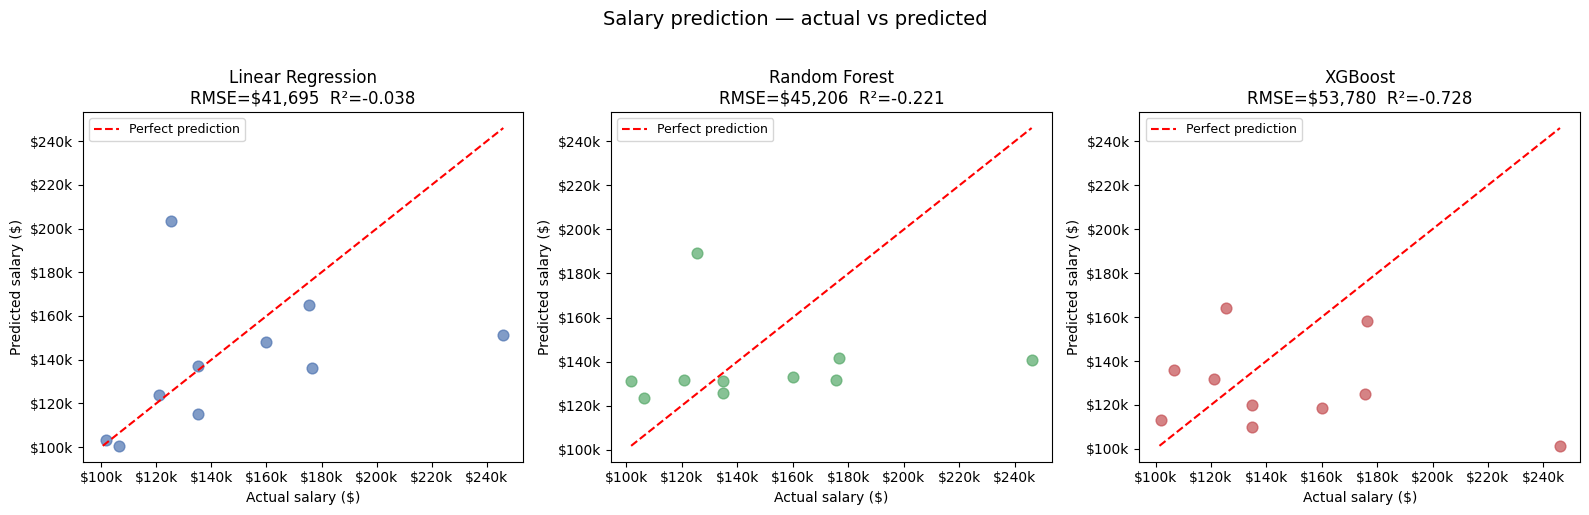


Model comparison summary:
Model                           RMSE       R²    CV R²
-------------------------------------------------------
Linear Regression         $   41,695   -0.038   -2.579
Random Forest             $   45,206   -0.221   -1.391
XGBoost                   $   53,780   -0.728   -1.693


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ["#4C72B0", "#55A868", "#C44E52"]

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]
    
    # Scatter plot — predicted vs actual
    ax.scatter(y_test, result["predictions"], 
               alpha=0.7, color=colors[idx], s=60)
    
    # Perfect prediction line
    min_val = min(y_test.min(), result["predictions"].min())
    max_val = max(y_test.max(), result["predictions"].max())
    ax.plot([min_val, max_val], [min_val, max_val], 
            "r--", linewidth=1.5, label="Perfect prediction")
    
    ax.set_xlabel("Actual salary ($)")
    ax.set_ylabel("Predicted salary ($)")
    ax.set_title(f"{name}\nRMSE=${result['rmse']:,.0f}  R²={result['r2']:.3f}")
    ax.legend(fontsize=9)
    
    # Format axis labels as thousands
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f"${x/1000:.0f}k")
    )
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f"${x/1000:.0f}k")
    )

plt.suptitle("Salary prediction — actual vs predicted", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../data/cleaned/salary_model_comparison.png", 
            dpi=150, bbox_inches="tight")
plt.show()

# Print summary table
print("\nModel comparison summary:")
print("=" * 55)
print(f"{'Model':<25} {'RMSE':>10} {'R²':>8} {'CV R²':>8}")
print("-" * 55)
for name, result in results.items():
    print(f"{name:<25} ${result['rmse']:>9,.0f} "
          f"{result['r2']:>8.3f} "
          f"{result['cv_r2_mean']:>8.3f}")

In [37]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

X_simple = features_simple.values
y_simple = salary_df["salary_avg"].values

# Test all three models with LOO-CV
loo_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
                         n_estimators=100, 
                         random_state=42
                     ),
    "XGBoost": xgb.XGBRegressor(
                   n_estimators=100,
                   learning_rate=0.1,
                   random_state=42,
                   verbosity=0
               )
}

print("Running Leave-One-Out Cross Validation...")
print("(tests on every single job one at a time)")

loo_results = {}

for name, model in loo_models.items():
    predictions = []
    actuals = []
    
    # Scale for linear regression
    if name == "Linear Regression":
        scaler = StandardScaler()
    
    for train_idx, test_idx in loo.split(X_simple):
        X_tr = X_simple[train_idx]
        X_te = X_simple[test_idx]
        y_tr = y_simple[train_idx]
        y_te = y_simple[test_idx]
        
        # Scale inside the loop to prevent data leakage
        if name == "Linear Regression":
            X_tr = scaler.fit_transform(X_tr)
            X_te = scaler.transform(X_te)
        
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        
        predictions.append(pred[0])
        actuals.append(y_te[0])
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    r2 = r2_score(actuals, predictions)
    
    loo_results[name] = {
        "rmse": rmse,
        "r2": r2,
        "predictions": predictions,
        "actuals": actuals
    }
    
    print(f"\n{name}:")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  R²:   {r2:.3f}")

print("\n" + "=" * 50)
print("Best model:", min(loo_results, 
      key=lambda x: loo_results[x]["rmse"]))

Running Leave-One-Out Cross Validation...
(tests on every single job one at a time)

Linear Regression:
  RMSE: $46,792
  R²:   -0.220

Random Forest:
  RMSE: $45,264
  R²:   -0.142

XGBoost:
  RMSE: $51,482
  R²:   -0.477

Best model: Random Forest


Top title terms found:
['ai' 'analyst' 'data' 'data analyst' 'data engineer' 'data scientist'
 'engineer' 'learning' 'learning engineer' 'machine' 'machine learning'
 'ml' 'ml engineer' 'nlp' 'nlp engineer' 'operations' 'remote' 'scientist'
 'senior' 'sr']

Combined feature matrix: (47, 33)
Was: (47, 13) → Now: (47, 33)

Running LOO-CV with title features added...

Random Forest + Title Features (LOO-CV):
  RMSE: $44,229
  R²:   -0.090


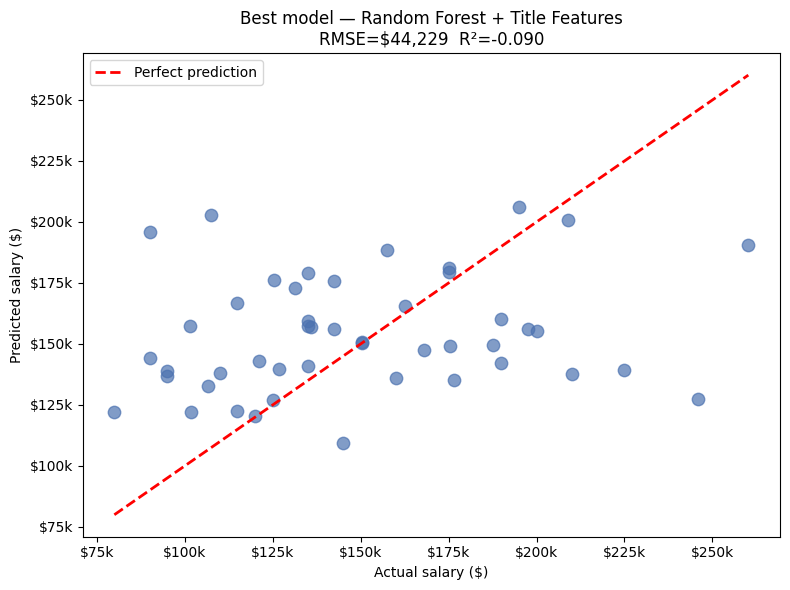

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# Job titles contain huge salary signals
# "Senior", "Principal", "Lead", "Junior" etc
tfidf = TfidfVectorizer(
    max_features=20,
    ngram_range=(1, 2),
    stop_words="english"
)

title_features = tfidf.fit_transform(
    salary_df["title"].fillna("")
)

print("Top title terms found:")
print(tfidf.get_feature_names_out())

# Combine skill features with title features
X_combined = hstack([
    csr_matrix(X_simple),
    title_features
]).toarray()

print(f"\nCombined feature matrix: {X_combined.shape}")
print(f"Was: {X_simple.shape} → Now: {X_combined.shape}")

# Run LOO-CV again with combined features
print("\nRunning LOO-CV with title features added...")

best_model = RandomForestRegressor(
    n_estimators=100, 
    random_state=42
)

predictions = []
actuals = []

for train_idx, test_idx in loo.split(X_combined):
    X_tr = X_combined[train_idx]
    X_te = X_combined[test_idx]
    y_tr = y_simple[train_idx]
    y_te = y_simple[test_idx]
    
    best_model.fit(X_tr, y_tr)
    pred = best_model.predict(X_te)
    predictions.append(pred[0])
    actuals.append(y_te[0])

predictions = np.array(predictions)
actuals = np.array(actuals)

rmse = np.sqrt(mean_squared_error(actuals, predictions))
r2 = r2_score(actuals, predictions)

print(f"\nRandom Forest + Title Features (LOO-CV):")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  R²:   {r2:.3f}")

# Plot final model results
plt.figure(figsize=(8, 6))
plt.scatter(actuals, predictions, 
            alpha=0.7, color="#4C72B0", s=80)

min_val = min(actuals.min(), predictions.min())
max_val = max(actuals.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val],
         "r--", linewidth=2, label="Perfect prediction")

plt.xlabel("Actual salary ($)")
plt.ylabel("Predicted salary ($)")
plt.title(f"Best model — Random Forest + Title Features\n"
          f"RMSE=${rmse:,.0f}  R²={r2:.3f}")
plt.legend()

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x/1000:.0f}k")
)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x/1000:.0f}k")
)

plt.tight_layout()
plt.savefig("../data/cleaned/best_salary_model.png", 
            dpi=150)
plt.show()